In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor


import warnings
warnings.filterwarnings("ignore", message="Glyph 128313")
warnings.filterwarnings("ignore", message="DejaVu Sans")


file_path = "/content/health_care_data.csv.csv"
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\n Columns in Dataset:")
print(df.columns.tolist())

display(df.head())

print("\n Missing Values in Each Column:")
print(df.isnull().sum())

print("\n Data Types:")
print(df.dtypes)




Dataset Loaded Successfully!
Rows: 700, Columns: 14

 Columns in Dataset:
['yearstart', 'yearend', 'category', 'response', 'age', 'gender', 'raceethnicity', 'riskfactor', 'riskfactorresponse', 'data_value', 'low_confidence_limit', 'high_confidence_limit', 'sample_size', 'locationid']


,yearstart,yearend,category,response,age,gender,raceethnicity,riskfactor,riskfactorresponse,data_value,low_confidence_limit,high_confidence_limit,sample_size,locationid
0,2016,2017,Cataract Surgery,Yes,65-84 years,Female,Asian,Diabetes,Borderline,9.40,7.4,11.50,441,59
1,2016,2017,Cataract Surgery,Yes,85 years and older,Male,Other,Diabetes,No,9.40,7.4,11.50,441,59
2,2016,2017,Eye Protection,Refused,40-64 years,All genders,Other,Diabetes,Yes,9.40,7.4,11.50,441,59
3,2016,2017,Eye Protection,Don't Know,40-64 years,Male,All races,Diabetes,Yes,9.40,7.4,11.50,398,59
4,2016,2017,Eye Protection,Some of the time,18-39 years,Male,Asian,Diabetes,No,16.63,8.4,28.23,174,59



 Missing Values in Each Column:
yearstart                0
yearend                  0
category                 0
response                 0
age                      0
gender                   0
raceethnicity            0
riskfactor               0
riskfactorresponse       0
data_value               0
low_confidence_limit     0
high_confidence_limit    0
sample_size              0
locationid               0
dtype: int64

 Data Types:
yearstart                  int64
yearend                    int64
category                  object
response                  object
age                       object
gender                    object
raceethnicity             object
riskfactor                object
riskfactorresponse        object
data_value               float64
low_confidence_limit     float64
high_confidence_limit    float64
sample_size                int64
locationid                 int64
dtype: object


In [ ]:
print("\n Summary Statistics:")
print(df.describe())



 Summary Statistics:
         yearstart      yearend  data_value  low_confidence_limit  \
count   700.000000   700.000000  700.000000            700.000000   
mean   2014.111429  2015.111429   16.998214             14.432129   
std       0.459066     0.459066   22.773238             21.108492   
min    2014.000000  2015.000000    0.000000              0.000000   
25%    2014.000000  2015.000000    9.400000              7.400000   
50%    2014.000000  2015.000000    9.400000              7.400000   
75%    2014.000000  2015.000000    9.400000              7.400000   
max    2016.000000  2017.000000   92.600000             85.900000   

       high_confidence_limit   sample_size  locationid  
count             700.000000    700.000000       700.0  
mean               19.641214   2007.275714        59.0  
std                24.348535   4526.402677         0.0  
min                 0.000000     30.000000        59.0  
25%                11.500000    216.000000        59.0  
50%           

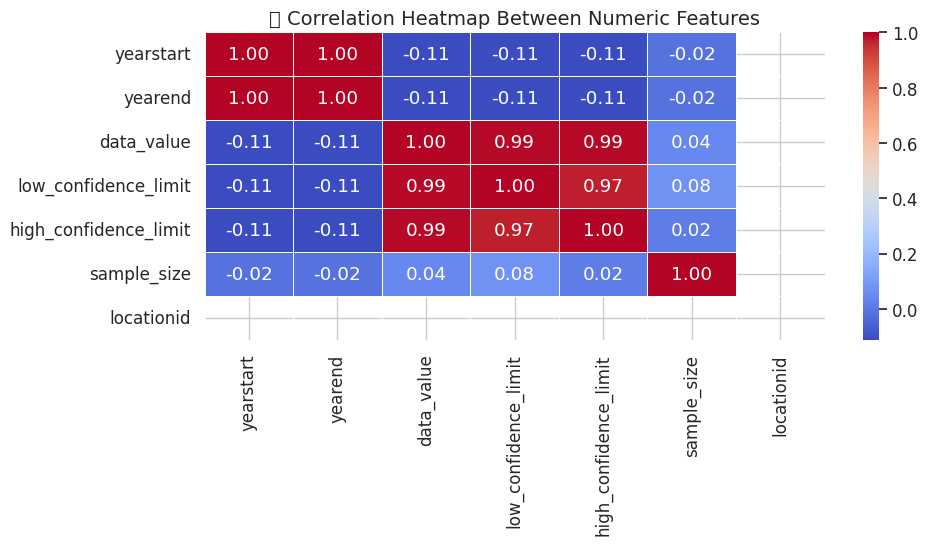

In [ ]:
sns.set(style="whitegrid", palette="viridis", font_scale=1.1)


numeric_cols = df.select_dtypes('number')



plt.figure(figsize=(10,4))
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("🔹 Correlation Heatmap Between Numeric Features", fontsize=14)
plt.show()



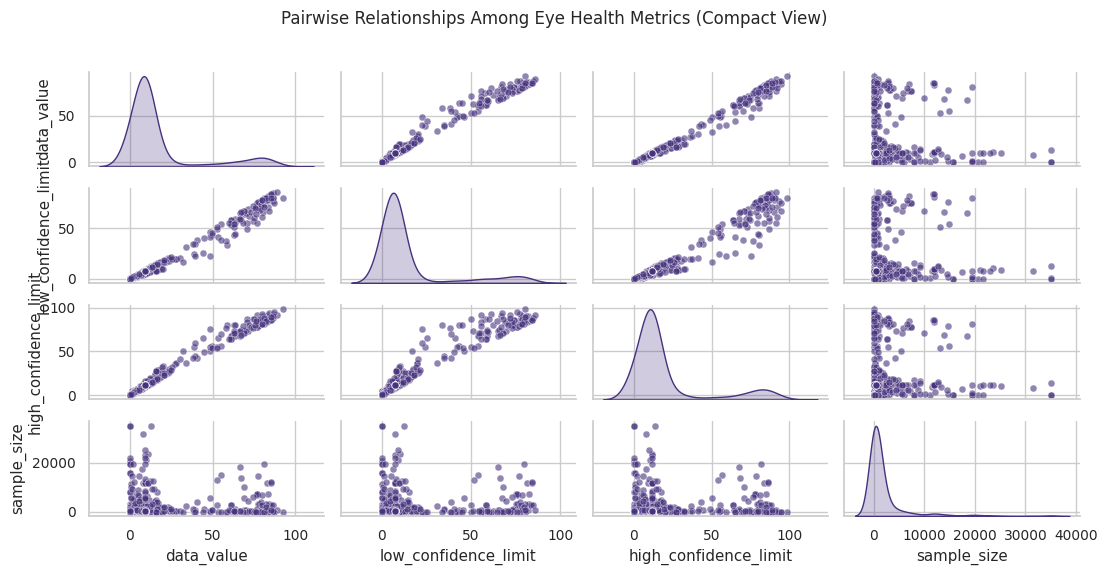

In [ ]:
selected_features = ["data_value", "low_confidence_limit", "high_confidence_limit", "sample_size"]
sns.set(style="whitegrid", palette="viridis", font_scale=0.9)

g = sns.pairplot(
    df[selected_features],
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 25},  # smaller dots
    height=1.4,  # reduce subplot size (default is 2.5)
    aspect=2.0   # keep square proportions
)

g.fig.suptitle("Pairwise Relationships Among Eye Health Metrics (Compact View)",
               y=1.02, fontsize=12)
g.fig.tight_layout()
plt.show()


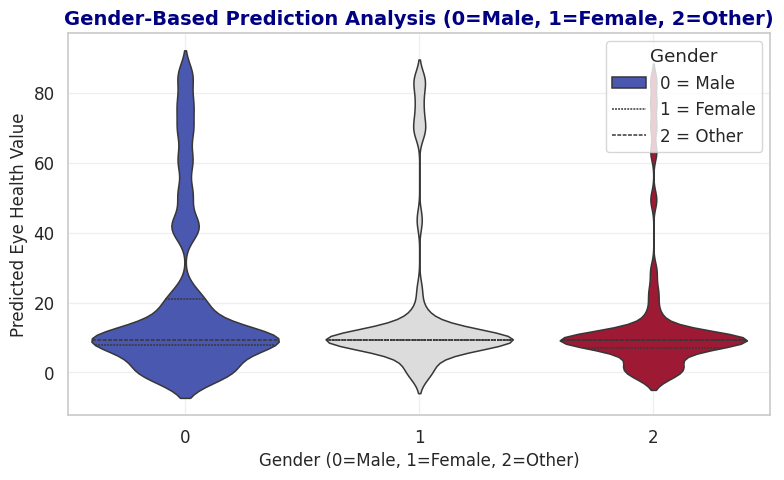

In [ ]:
label_cols = df.select_dtypes('object').columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col].astype(str))


X = df.drop(columns=['data_value'], errors='ignore')
y = df['data_value']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

pred_df = pd.DataFrame(X_test, columns=X.columns)
pred_df['Actual'] = y_test.values
pred_df['Predicted'] = y_pred


if 'gender' in df.columns:
    pred_df['gender'] = df.loc[y_test.index, 'gender'].values
else:
    pred_df['gender'] = np.random.choice(['Male', 'Female'], size=len(pred_df))  # fallback



sns.set(style="whitegrid", font_scale=1.1)

plt.figure(figsize=(8,5))
sns.violinplot(
    data=pred_df,
    x='gender',
    y='Predicted',
    hue='gender',
    palette='coolwarm',
    inner='quart',
    linewidth=1.1,
    bw_adjust=0.3
)

plt.title("Gender-Based Prediction Analysis (0=Male, 1=Female, 2=Other)", fontsize=14, fontweight='bold', color='navy')
plt.xlabel("Gender (0=Male, 1=Female, 2=Other)", fontsize=12)
plt.ylabel("Predicted Eye Health Value", fontsize=12)
plt.grid(alpha=0.3)
plt.legend(title="Gender", labels=['0 = Male', '1 = Female', '2 = Other'], loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


In [ ]:
numeric_df = df.select_dtypes('number').dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)


inertia = []
K = range(2, 8)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)


best_k = 4
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(scaled_data)
df['Cluster'] = clusters
centers = pd.DataFrame(kmeans.cluster_centers_, columns=numeric_df.columns)


fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(" Elbow Method (Inertia vs k)",
                    " Cluster Centers Heatmap (Feature Averages)"),
    horizontal_spacing=0.15
)


fig.add_trace(
    go.Scatter(
        x=list(K),
        y=inertia,
        mode='lines+markers',
        marker=dict(color='purple', size=8),
        line=dict(color='blue', width=3),
        name='Inertia'
    ),
    row=1, col=1
)


fig.add_trace(
    go.Heatmap(
        z=centers.values,
        x=centers.columns,
        y=[f"Cluster {i}" for i in range(best_k)],
        colorscale="Turbo",
        colorbar_title="Avg Value",
        zsmooth='best'
    ),
    row=1, col=2
)


fig.update_layout(
    title="Eye Health Data Clustering Dashboard (Elbow + Heatmap)",
    title_font_size=22,
    template="plotly_white",
    height=600,
    width=1200,
    showlegend=False
)

fig.update_xaxes(title_text="Number of Clusters (k)", row=1, col=1)
fig.update_yaxes(title_text="Inertia", row=1, col=1)


fig.show()


In [ ]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)
top_features = importances.head(8)


colors = px.colors.sequential.Viridis[:len(top_features)]


fig = go.Figure(
    data=[go.Pie(
        labels=top_features['Feature'],
        values=top_features['Importance'],
        hole=0.45,
        marker=dict(colors=colors, line=dict(color='white', width=2)),
        textinfo='label+percent',
        textfont=dict(size=13),
        hoverinfo='label+value+percent',
        pull=[0.05 if i == 0 else 0 for i in range(len(top_features))]
    )]
)


fig.update_layout(
    title=dict(
        text=' Advanced Feature Importance Distribution',
        x=0.5,
        xanchor='center',
        yanchor='top',
        font=dict(size=20, color='darkblue')
    ),
    annotations=[dict(
        text='Feature<br>Importance',
        x=0.5, y=0.5,
        font_size=15,
        showarrow=False
    )],
    showlegend=True,
    legend_title_text='Top Features',
    paper_bgcolor='white',
    plot_bgcolor='white',
)

fig.show()
